# ViT Attention Analysis: Memory-Optimized Unified Function
This notebook provides a single, memory-efficient function to compute CKA similarity across all attention heads for any Hugging Face Vision Transformer.

In [1]:
!pip install transformers datasets torch torchvision matplotlib seaborn tqdm

In [31]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import gc
from tqdm import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from transformers import AutoModelForImageClassification

def analyze_vit_attention(model_name, dataset_name, num_samples=500, batch_size=16):
    """
    Analyzes ViT attention head similarity using CKA with memory optimizations.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # 1. Load Model
    print(f"Loading model: {model_name}...")
    model = AutoModelForImageClassification.from_pretrained(
        model_name,
        output_attentions=True,
        attn_implementation="eager"
    ).to(device)
    model.eval()

    # 2. Setup Dataset
    transform_list = [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]
    if dataset_name in ['MNIST', 'FashionMNIST']:
        transform_list.insert(0, transforms.Grayscale(num_output_channels=3))

    transform = transforms.Compose(transform_list)
    ds_class = getattr(datasets, dataset_name)
    full_dataset = ds_class(root='./data', train=False, download=True, transform=transform)

    indices = np.random.choice(len(full_dataset), min(num_samples, len(full_dataset)), replace=False)
    subset = Subset(full_dataset, indices)
    dataloader = DataLoader(subset, batch_size=batch_size, shuffle=False)

    # 3. Collect Attention Maps (Memory Efficient)
    head_features = []


    print(f"Processing {len(subset)} samples...")
    num_images = 0
    with torch.no_grad():
        for batch_idx, (images, _) in enumerate(tqdm(dataloader)):
            images = images.to(device)
            outputs = model(images)


            if batch_idx == 0:
                num_layers = len(outputs.attentions)
                num_heads = outputs.attentions[0].shape[1]
                total_heads = num_layers * num_heads
                head_features = [[] for _ in range(total_heads)]
                total_cka_matrix = torch.zeros((total_heads, total_heads), device='cpu', dtype=torch.float64)

            all_layers = torch.stack(outputs.attentions)
            batch_size = images.shape[0]
            all_heads = all_layers.permute(1, 0, 2, 3, 4).reshape(batch_size, total_heads, -1)

            for i in range(batch_size):
              heads = all_heads[i]  #

              # Center each head's features (already doing this)
              heads = heads - heads.mean(dim=1, keepdim=True)

              # For linear CKA: HSIC(X,Y) = ||X^T Y||_F^2 / n^2
              # heads is [72, d], so cross-gram = heads @ heads.T gives [72, 72]
              # but each entry (i,j) = h_i · h_j, and we need ||h_i^T h_j||_F^2
              # For 1D vectors, ||h_i · h_j||_F^2 = (h_i · h_j)^2

              gram = heads @ heads.T  # [72, 72], entry (i,j) = dot(h_i, h_j)

              # Numerator: HSIC = (dot(h_i, h_j))^2
              numerator = gram ** 2  # element-wise square

              # Denominator: sqrt(HSIC(i,i) * HSIC(j,j)) = sqrt((h_i·h_i)^2 * (h_j·h_j)^2)
              #            = (h_i·h_i) * (h_j·h_j) = diag^2 outer product...
              # simplifies to: diag[i] * diag[j]
              norms = torch.diag(gram)  # [72], each entry = ||h_i||^2
              normalization = norms.unsqueeze(0) * norms.unsqueeze(1)  # outer product

              img_cka = numerator / (normalization + 1e-8)
              total_cka_matrix += img_cka.double().cpu()
              num_images += 1

    average_cka_matrix = total_cka_matrix / num_images


    plt.figure(figsize=(12, 10))
    sns.heatmap(average_cka_matrix, cmap='viridis', square=True)
    plt.title(f"CKA: {model_name} on {dataset_name} ({num_samples} samples)")
    for i in range(0, total_heads, num_heads):
        plt.axhline(i, color='white', lw=0.5)
        plt.axvline(i, color='white', lw=0.5)
    plt.savefig(f"vitbaseCIFAR10_500.pdf")
    plt.show()

    return average_cka_matrix

Using device: cpu
Loading model: google/vit-base-patch16-224...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Processing 500 samples...



100%|██████████| 32/32 [06:16<00:00, 11.78s/it]


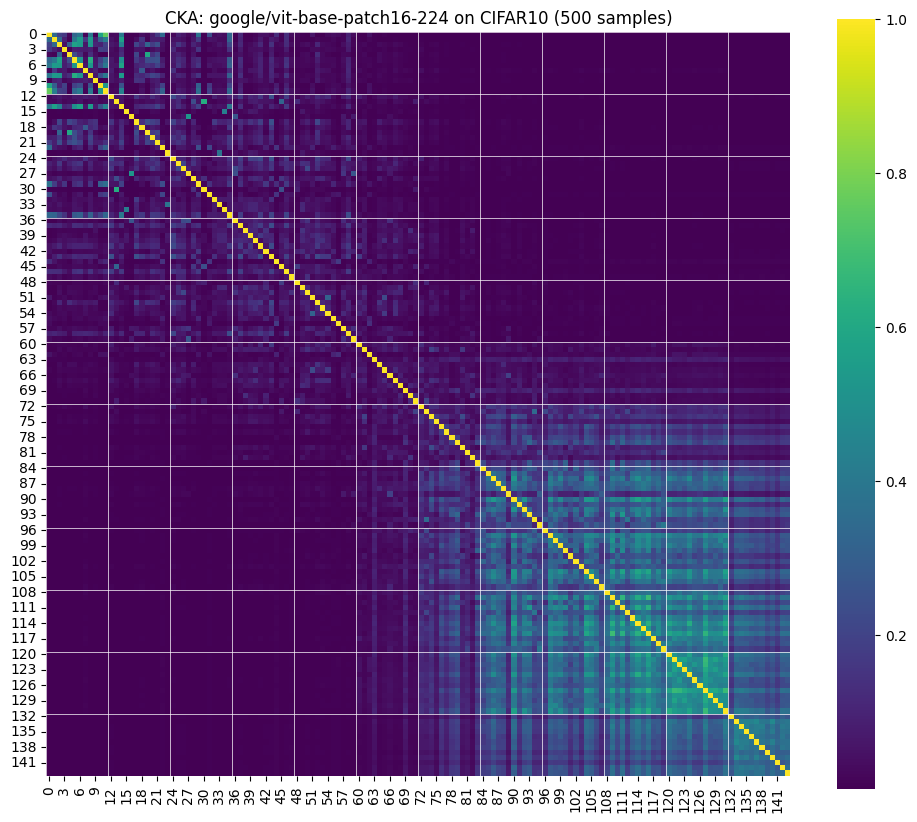

In [32]:
# RUN ANALYSIS HERE
# MNIST CIFAR10 CIFAR100 FashionMNIST
matrix = analyze_vit_attention("google/vit-base-patch16-224", "CIFAR10", num_samples=500)